# `ModelFEMSolver` Examples

This notebook demonstrates the P1 finite-element solver on two problems that
the spectral solver **cannot** handle:

| Example | Mesh type | PDE |
|---------|-----------|-----|
| 1. Flat 2-D Poisson | Unstructured triangles in $\mathbb{R}^2$ | $-\Delta u = f$ |
| 2. Surface Laplacian | Triangulated sphere in $\mathbb{R}^3$ | $-\Delta_\Gamma u = f$ |

Both use the same `ModelFEMSolver` with the **same API** as `ModelSpectralSolver`.

**Assembly** is GPU-accelerated via `jax.vmap` over elements.  
**Solver backend** is `'cg'` (JAX CG with Jacobi preconditioner) by default;
use `solver_backend='petsc'` for large meshes with BoomerAMG.

In [1]:
import pinns
import pinns.meshes as meshes
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

print(pinns.ModelFEMSolver)


<class 'pinns.models.model_fem_solver.ModelFEMSolver'>


## Example 1: Flat 2-D Poisson on Irregular Domain

We solve the manufactured-solution problem on the unit square:

$$-\Delta u = 2\pi^2 \sin(\pi x)\sin(\pi y), \quad (x,y)\in[0,1]^2$$

with $u = 0$ on the boundary. The exact solution is $u = \sin(\pi x)\sin(\pi y)$.

The mesh is generated by `pinns.meshes.square` — an **unstructured triangulation**
via pygmsh that the spectral solver cannot handle.


In [2]:
# ── Unstructured mesh via pinns.meshes ────────────────────────────────────────
verts, faces = meshes.square(x_max=1.0, y_max=1.0, mesh_size=0.05)
domain = pinns.DomainMesh((verts, faces))
print(f"Vertices: {len(verts)}   Triangles: {len(faces)}")


Vertices: 568   Triangles: 1054


In [3]:
# ── Define weak-form integrand ───────────────────────────────────────────────
def volume_fn(x, y, params, phi, derivative):
    """Galerkin residual: a(u, φ) − ℓ(φ)  =  ∫ κ ∇u·∇φ dΩ − ∫ f φ dΩ"""
    du_dx   = derivative(y,   x, 0, (0,))   # ∂u/∂x  — trial gradient
    du_dy   = derivative(y,   x, 0, (1,))   # ∂u/∂y
    dphi_dx = derivative(phi, x, 0, (0,))   # ∂φ/∂x  — test gradient
    dphi_dy = derivative(phi, x, 0, (1,))   # ∂φ/∂y
    f = 2.0 * jnp.pi**2 * jnp.sin(jnp.pi * x[:, 0]) * jnp.sin(jnp.pi * x[:, 1])
    return params["kappa"] * (du_dx * dphi_dx + du_dy * dphi_dy) - f * phi

# ── Assemble and solve ────────────────────────────────────────────────────────
fem = pinns.ModelFEMSolver(domain, ["u"])
fem.add_parameter("kappa", 1.0)
fem.add_inner(volume_fn, name="poisson")
fem.add_dirichlet(lambda X: jnp.zeros(X.shape[0]))   # u = 0 on ∂Ω

result = fem.solve()
u_fem = result["u"]

# ── Error vs exact solution ───────────────────────────────────────────────────
u_exact = np.sin(np.pi * verts[:, 0]) * np.sin(np.pi * verts[:, 1])
interior_mask = np.setdiff1d(np.arange(len(verts)), fem._boundary_nodes)
err_max = np.max(np.abs(u_fem[interior_mask] - u_exact[interior_mask]))
print(f"Max error (interior): {err_max:.4f}")
print(fem)


Max error (interior): 0.0029
ModelFEMSolver(n_vertices=568, n_faces=1054, n_dims=2, element='P1', backend='cg')


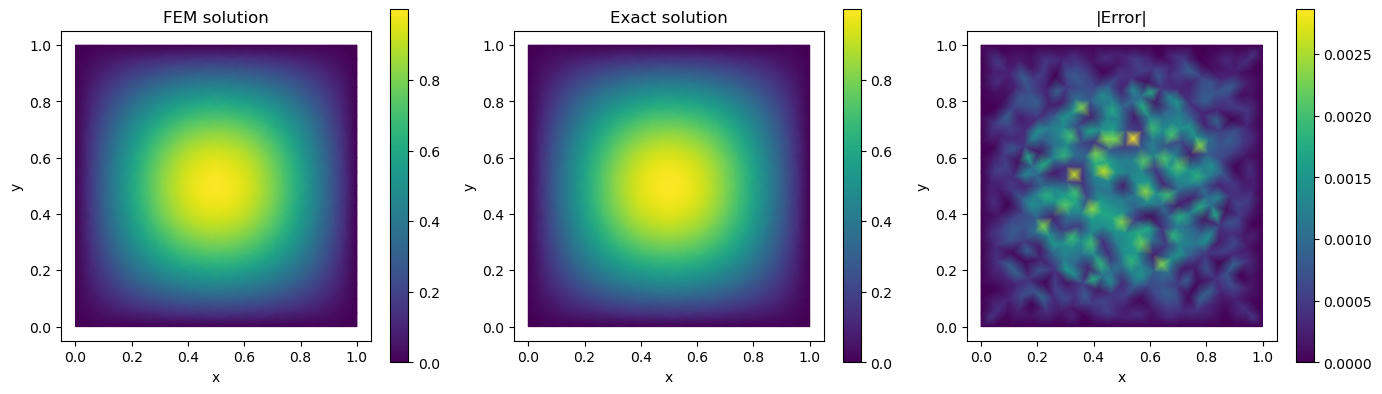

In [4]:
# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, vals, title in zip(axes,
                            [u_fem, u_exact, np.abs(u_fem - u_exact)],
                            ["FEM solution", "Exact solution", "|Error|"]):
    sc = ax.tripcolor(verts[:, 0], verts[:, 1], faces, vals,
                      cmap="viridis", shading="gouraud")
    plt.colorbar(sc, ax=ax)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlabel("x"); ax.set_ylabel("y")

plt.tight_layout()
plt.show()


## Example 2: Surface Laplacian on a Sphere

We solve the surface Poisson equation on the unit sphere $\mathbb{S}^2$:

$$-\Delta_\Gamma u = f, \quad \text{on } \mathbb{S}^2$$

using the **spherical harmonic** $Y_1^0 = \cos\theta$ as the manufactured solution.
On the sphere, $-\Delta_\Gamma Y_\ell^m = \ell(\ell+1)Y_\ell^m$, so for $\ell=1$:

$$-\Delta_\Gamma (\cos\theta) = 2\cos\theta$$

In Cartesian coordinates: $u = z/r$, $f = 2z/r$.

The mesh is a **triangulated 2-D manifold in $\mathbb{R}^3$** — the spectral
solver cannot handle this at all.

In [5]:
# ── Icosphere mesh via pinns.meshes ──────────────────────────────────────────
verts_s, faces_s = meshes.sphere(subdivisions=4)   # ~2562 vertices, ~5120 faces
domain_s = pinns.DomainMesh((verts_s, faces_s))
print(f"Sphere mesh: {len(verts_s)} vertices, {len(faces_s)} triangles")


Sphere mesh: 2562 vertices, 5120 triangles


In [6]:
def volume_fn_sphere(x, y, params, phi, derivative):
    """Galerkin residual for surface Laplacian: ∫ ∇_Γu·∇_Γφ − 2z·φ dΓ"""
    du_dx   = derivative(y,   x, 0, (0,))
    du_dy   = derivative(y,   x, 0, (1,))
    du_dz   = derivative(y,   x, 0, (2,))
    dphi_dx = derivative(phi, x, 0, (0,))
    dphi_dy = derivative(phi, x, 0, (1,))
    dphi_dz = derivative(phi, x, 0, (2,))
    f = 2.0 * x[:, 2]   # f = 2z = 2cos(θ) on unit sphere
    return (du_dx*dphi_dx + du_dy*dphi_dy + du_dz*dphi_dz) - f * phi

fem_s = pinns.ModelFEMSolver(domain_s, ["u"])
fem_s.add_inner(volume_fn_sphere, name="surface_laplacian")

# Constrain mean by pinning node 0 to its exact value u = z
fem_s.add_dirichlet(
    value_fn=lambda X: X[:, 2],
    nodes=np.array([0]),
)

result_s = fem_s.solve()
u_s = result_s["u"]

u_exact_s = verts_s[:, 2]   # u = z = cos(θ) on unit sphere
err_s = np.max(np.abs(u_s - u_exact_s))
print(f"Max error on sphere: {err_s:.4f}")
print(fem_s)


Max error on sphere: 0.0021
ModelFEMSolver(n_vertices=2562, n_faces=5120, n_dims=3, element='P1', backend='cg')


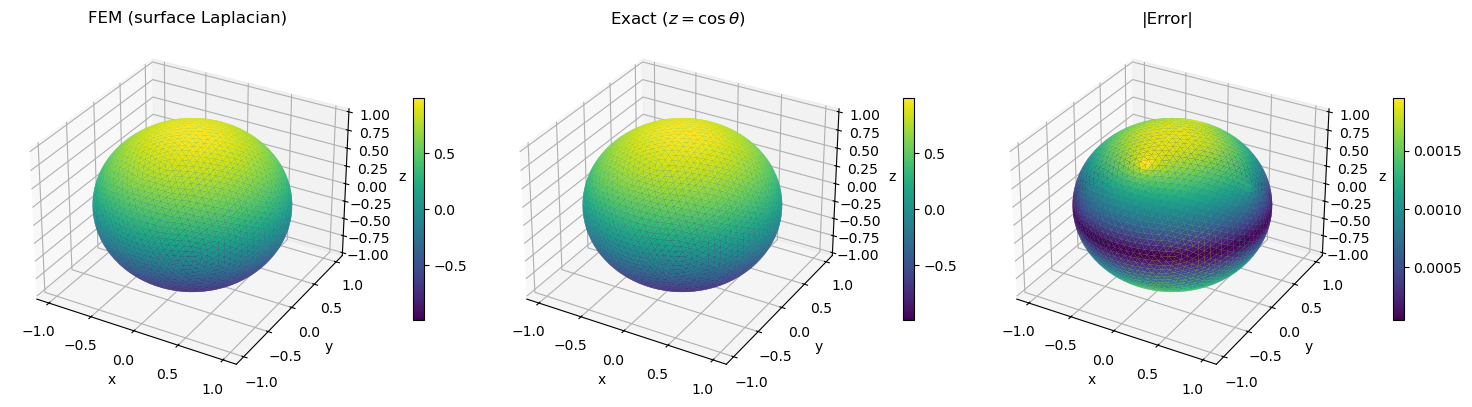

In [7]:
# Visualise on sphere (3-D surface plot)
import matplotlib.cm as cm
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 3, figsize=(15, 4),
                          subplot_kw={"projection": "3d"})

for ax, vals, title in zip(axes,
                            [u_s, u_exact_s, np.abs(u_s - u_exact_s)],
                            ["FEM (surface Laplacian)",
                             "Exact ($z = \\cos\\theta$)",
                             "|Error|"]):
    face_vals = vals[faces_s].mean(axis=1)
    v_min, v_max = face_vals.min(), face_vals.max()
    norm = mcolors.Normalize(vmin=v_min, vmax=v_max)
    face_colors = cm.viridis(norm(face_vals))

    surf = ax.plot_trisurf(verts_s[:, 0], verts_s[:, 1], verts_s[:, 2],
                           triangles=faces_s, shade=False)
    surf.set_facecolor(face_colors)

    sm = cm.ScalarMappable(cmap="viridis", norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.1)

    ax.set_title(title)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")

plt.tight_layout()
plt.show()